In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv')
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


<Axes: >

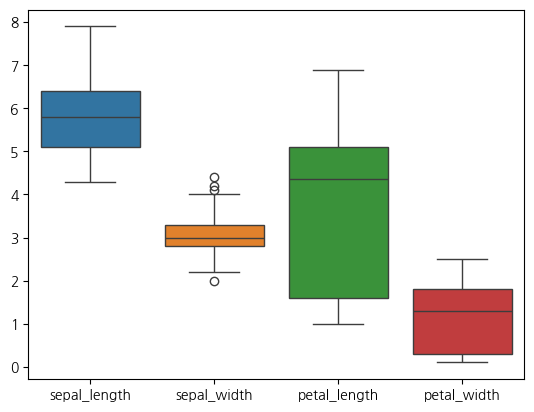

In [4]:
# 크게 조작할 데이터 없음
sns.boxplot(data)

In [5]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
X = data.drop('species', axis=1)
y = data['species']

In [7]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

In [8]:
# 여긴 원핫인코딩
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 숫자가 크게 차이나진 않지만, 스케일링을 진행
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [17]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [18]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [19]:
mms_X_train.shape

(120, 4)

In [20]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequencial API

In [21]:
from keras.models import Sequential
from keras.layers import Dense, Input

In [26]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation="softmax"))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중 분류의 경우 사용하는 loss
    * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우 
    * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding된 경우

Epoch 1/100


I0000 00:00:1747337491.041071   87346 service.cc:152] XLA service 0x7f15d800b650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747337491.041115   87346 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-16 04:31:31.057959: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747337491.175254   87346 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/8 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4375 - loss: 1.1755

I0000 00:00:1747337492.169287   87346 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.3660 - loss: 1.2083 - val_accuracy: 0.3333 - val_loss: 1.2192
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4714 - loss: 1.1562 - val_accuracy: 0.6000 - val_loss: 1.1811
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6930 - loss: 1.1415 - val_accuracy: 0.6000 - val_loss: 1.1498
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5888 - loss: 1.1124 - val_accuracy: 0.4000 - val_loss: 1.1313
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4300 - loss: 1.1141 - val_accuracy: 0.4000 - val_loss: 1.1170
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3416 - loss: 1.1078 - val_accuracy: 0.4333 - val_loss: 1.1010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4715 - loss: 1.0952 - val_accuracy: 0.6000 - val_loss: 1.0896
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5723 - loss: 1.0875 - val_accuracy: 0.6000 - val_loss: 1.0851
Epoch 9/1

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7035 - loss: 0.6255 - val_accuracy: 0.6333 - val_loss: 0.6681
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7046 - loss: 0.6596 - val_accuracy: 0.6333 - val_loss: 0.6649
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6015 - loss: 0.7068 - val_accuracy: 0.6333 - val_loss: 0.6618
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6884 - loss: 0.6471 - val_accuracy: 0.6333 - val_loss: 0.6588
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6534 - loss: 0.6660 - val_accuracy: 0.6333 - val_loss: 0.6559
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6423 - loss: 0.6026 - val_accuracy: 0.6333 - val_loss: 0.6532
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6894 - loss: 0.6389 - val_accuracy: 0.6333 - val_loss: 0.6506
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6680 - loss: 0.6334 - val_accuracy: 0.6333 - val_loss: 0.6482
Ep

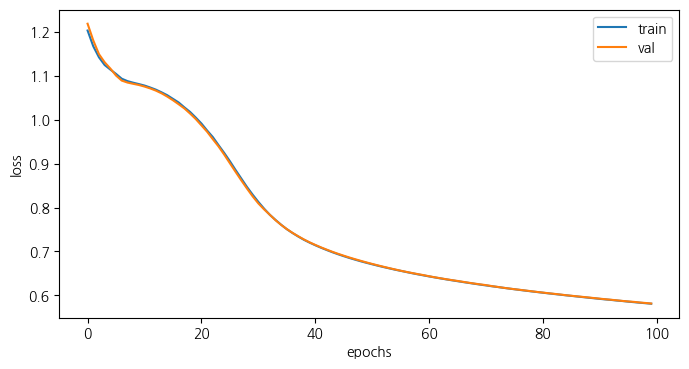

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.160713,0.425624,0.413663
18,True,False,False,0.997582,0.001449,0.000969
118,False,False,True,0.161753,0.429034,0.409213
78,False,True,False,0.160713,0.425624,0.413663
76,False,True,False,0.160713,0.425624,0.413663
31,True,False,False,0.993045,0.004106,0.002849
64,False,True,False,0.195407,0.430652,0.373941
141,False,False,True,0.160713,0.425624,0.413663
68,False,True,False,0.163729,0.435609,0.400662
82,False,True,False,0.160713,0.425624,0.413663


In [27]:
# one-hot encoding을 한 경우
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

In [28]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [29]:
pd.DataFrame(pred)

,0,1,2
73,0.160713,0.425624,0.413663
18,0.997582,0.001449,0.000969
118,0.161753,0.429034,0.409213
78,0.160713,0.425624,0.413663
76,0.160713,0.425624,0.413663
31,0.993045,0.004106,0.002849
64,0.195407,0.430652,0.373941
141,0.160713,0.425624,0.413663
68,0.163729,0.435609,0.400662
82,0.160713,0.425624,0.413663


함수형 API

In [30]:
from keras.models import Model

In [32]:
inputs = Input(shape=(mms_X_train.shape[1],))
x = Dense(16, activation='relu')(inputs)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.3196 - loss: 1.0890 - val_accuracy: 0.3000 - val_loss: 1.0826
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2952 - loss: 1.0861 - val_accuracy: 0.3000 - val_loss: 1.0782
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3097 - loss: 1.0790 - val_accuracy: 0.3000 - val_loss: 1.0736
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3889 - loss: 1.0674 - val_accuracy: 0.3000 - val_loss: 1.0673
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3452 - loss: 1.0642 - val_accuracy: 0.3333 - val_loss: 1.0606
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3952 - loss: 1.0587 - val_accuracy: 0.4667 - val_loss: 1.0539
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4970 - loss: 1.0482 - val_accuracy: 0.5000 - val_loss: 1.0463
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5946 - loss: 1.0412 - val_accuracy: 0.5667 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.3504 - val_accuracy: 0.9333 - val_loss: 0.3258
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9730 - loss: 0.3475 - val_accuracy: 0.9333 - val_loss: 0.3196
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9685 - loss: 0.3303 - val_accuracy: 0.9333 - val_loss: 0.3133
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9672 - loss: 0.3367 - val_accuracy: 0.9333 - val_loss: 0.3077
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9806 - loss: 0.2861 - val_accuracy: 0.9333 - val_loss: 0.3013
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9420 - loss: 0.3166 - val_accuracy: 0.9667 - val_loss: 0.2957
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9708 - loss: 0.2848 - val_accuracy: 0.9667 - val_loss: 0.2895
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9667 - loss: 0.3031 - val_accuracy: 0.9333 - val

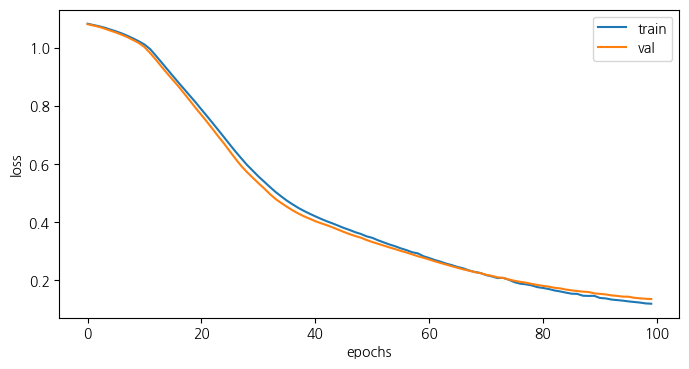

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,7.586572e-04,0.863802,0.135439
18,True,False,False,9.961839e-01,0.003523,0.000293
118,False,False,True,4.958056e-07,0.004440,0.995559
78,False,True,False,6.578938e-04,0.790632,0.208710
76,False,True,False,3.298401e-04,0.699485,0.300185
31,True,False,False,9.936526e-01,0.005759,0.000588
64,False,True,False,5.576355e-03,0.927770,0.066654
141,False,False,True,1.703499e-05,0.073141,0.926842
68,False,True,False,3.444281e-04,0.238200,0.761456
82,False,True,False,2.681748e-03,0.923237,0.074082


In [33]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

Subclass API

In [34]:
class Iris(Model):
    def __init__(self):
        super(Iris, self).__init__()
        self.dense1 =Dense(16, activation='relu')
        self.dense2 =Dense(8, activation='relu')
        self.dense3 =Dense(4, activation='relu')
        self.classifier = Dense(3, activation='softmax')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.classifier(x)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.3647 - loss: 1.1048 - val_accuracy: 0.3000 - val_loss: 1.1009
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3510 - loss: 1.0994 - val_accuracy: 0.3000 - val_loss: 1.1002
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.3180 - loss: 1.1002 - val_accuracy: 0.3000 - val_loss: 1.0996
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3759 - loss: 1.0980 - val_accuracy: 0.3000 - val_loss: 1.0993
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3629 - loss: 1.0973 - val_accuracy: 0.3000 - val_loss: 1.0990
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3675 - loss: 1.0967 - val_accuracy: 0.3000 - val_loss: 1.0985
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3745 - loss: 1.0960 - val_accuracy: 0.3000 - val_loss: 1.0969
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3423 - loss: 1.0950 - val_accuracy: 0.3000 - val_los

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7552 - loss: 0.4728 - val_accuracy: 0.7333 - val_loss: 0.4793
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7647 - loss: 0.4729 - val_accuracy: 0.8667 - val_loss: 0.4758
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8052 - loss: 0.4455 - val_accuracy: 0.8000 - val_loss: 0.4718
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7268 - loss: 0.4808 - val_accuracy: 0.6667 - val_loss: 0.4687
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7917 - loss: 0.4700 - val_accuracy: 0.8000 - val_loss: 0.4670
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6968 - loss: 0.5038 - val_accuracy: 0.7333 - val_loss: 0.4634
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6541 - loss: 0.4642 - val_accuracy: 0.7000 - val_loss: 0.4606
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6310 - loss: 0.4636 - val_accuracy: 0.7000 - v

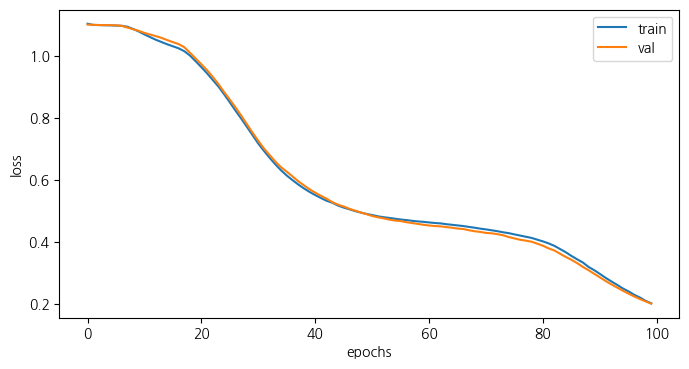

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.005430,0.805622,0.188948
18,True,False,False,0.998106,0.001886,0.000008
118,False,False,True,0.000001,0.073883,0.926115
78,False,True,False,0.003349,0.667037,0.329614
76,False,True,False,0.001572,0.669428,0.328999
31,True,False,False,0.994648,0.005311,0.000041
64,False,True,False,0.043485,0.836454,0.120060
141,False,False,True,0.000030,0.129250,0.870720
68,False,True,False,0.000173,0.286901,0.712926
82,False,True,False,0.018041,0.825808,0.156151


In [35]:
model2 = Iris()
model2.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model2.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model2.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result